# Preprocessing Pipeline — EEG-Based Emotion Recognition
## Case Study 2 Report 1 | Sanjeev Veeramani | Matriculation No. 100004303
### Supervisor: Prof. Dr. Binh Vu | SRH University Heidelberg | July 2026

---

### Objective
This report documents the complete EEG preprocessing pipeline applied to the **DEAP** (training + validation) and **SEED** (external test) datasets. The goal is to produce clean, normalized, and identically shaped EEG segments from both datasets, enabling cross-dataset emotion classification in subsequent reports.

### Datasets

| Property | DEAP | SEED |
|----------|------|------|
| Source | Koelstra et al. (2012) | Zheng & Lu (2015) |
| Subjects | 32 | 15 |
| EEG Channels | 32 | 62 |
| Sampling Rate | 128 Hz (preprocessed) | 200 Hz |
| Trials | 40 per subject | 15 per session × 3 sessions |
| Stimuli | Music videos (60s each) | Film clips (variable length) |
| Labels | Self-rated valence/arousal (1–9) | Pre-assigned: positive / neutral / negative |
| Role | Training + Validation | External Test Set |

---

## 1. Environment Setup

In [1]:
# Uncomment and run once to install packages
# !pip install numpy scipy matplotlib seaborn pandas openpyxl

import numpy as np
import pickle
import os
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, resample
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Configuration

All file paths and preprocessing parameters are defined centrally. The same filter, segmentation, and normalization parameters are applied to both DEAP and SEED to ensure consistency for cross-dataset evaluation.

In [2]:
# ============================================================
# FILE PATHS — Update these to match your machine
# ============================================================
DEAP_DATA_DIR = r"V:\Data_Analytics\case study 2\deap datset kaggle\deap-dataset\data_preprocessed_python"
SEED_DATA_DIR = r"V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\Preprocessed_EEG"
SEED_CHANNEL_FILE = r"V:\Data_Analytics\case study 2\seed dataset\channel_62_pos.locs"
OUTPUT_DIR = r"V:\Data_Analytics\case study 2\processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# PREPROCESSING PARAMETERS (applied identically to both datasets)
# ============================================================
DEAP_SRATE = 128         # DEAP sampling rate (Hz)
SEED_SRATE = 200         # SEED original sampling rate (Hz)
TARGET_SRATE = 128       # Resample SEED to match DEAP
LOW_FREQ = 4.0           # Bandpass lower cutoff (Hz)
HIGH_FREQ = 45.0         # Bandpass upper cutoff (Hz)
FILTER_ORDER = 5         # Butterworth filter order
WINDOW_SEC = 1           # Segmentation window (seconds)
OVERLAP = 0.5            # Overlap between windows
BASELINE_SEC = 3         # DEAP pre-stimulus baseline (seconds)
VALENCE_HIGH = 5.5       # DEAP valence threshold for Positive
VALENCE_LOW = 4.5        # DEAP valence threshold for Negative

# SEED trial labels — same for all sessions (Zheng & Lu, 2015)
SEED_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]

print("Configuration loaded.")
print(f"Bandpass filter: {LOW_FREQ}–{HIGH_FREQ} Hz | Window: {WINDOW_SEC}s | Overlap: {OVERLAP*100:.0f}%")

Configuration loaded.
Bandpass filter: 4.0–45.0 Hz | Window: 1s | Overlap: 50%


## 3. DEAP Data Exploration

Each subject's data is stored as a pickled `.dat` file. Before applying any preprocessing, we load one subject file to understand the raw data structure.

In [3]:
# Load Subject 01 to inspect data structure
sample_file = os.path.join(DEAP_DATA_DIR, 's01.dat')
with open(sample_file, 'rb') as f:
    raw = pickle.load(f, encoding='latin1')

eeg_raw = raw['data']
labels_raw = raw['labels']

print("DEAP Data Structure (Subject 01)")
print("=" * 55)
print(f"\nEEG data shape: {eeg_raw.shape}")
print(f"  → {eeg_raw.shape[0]} trials (music video clips)")
print(f"  → {eeg_raw.shape[1]} channels (32 EEG + 8 peripheral)")
print(f"  → {eeg_raw.shape[2]} time points ({eeg_raw.shape[2]/DEAP_SRATE:.0f}s = {BASELINE_SEC}s baseline + 60s stimulus)")
print(f"\nLabels shape: {labels_raw.shape}")
print(f"  → Columns: [Valence, Arousal, Dominance, Liking] (scale: 1–9)")
print(f"\nLabel ranges (Subject 01):")
for i, name in enumerate(['Valence', 'Arousal', 'Dominance', 'Liking']):
    col = labels_raw[:, i]
    print(f"  {name}: min={col.min():.2f}, max={col.max():.2f}, mean={col.mean():.2f}")

DEAP Data Structure (Subject 01)

EEG data shape: (40, 40, 8064)
  → 40 trials (music video clips)
  → 40 channels (32 EEG + 8 peripheral)
  → 8064 time points (63s = 3s baseline + 60s stimulus)

Labels shape: (40, 4)
  → Columns: [Valence, Arousal, Dominance, Liking] (scale: 1–9)

Label ranges (Subject 01):
  Valence: min=0.00, max=8.27, mean=3.12
  Arousal: min=1.00, max=8.15, mean=3.76
  Dominance: min=2.04, max=9.00, mean=5.90
  Liking: min=3.87, max=8.47, mean=6.85


## 4. Channel Identification

The DEAP preprocessed files contain numerical arrays without embedded channel metadata. Channel names follow the standard BioSemi 32-channel montage as documented in Koelstra et al. (2012), Table II. Only the first 32 channels (EEG) are retained; channels 33–40 (peripheral: EOG, EMG, GSR, respiration, blood volume, temperature) are discarded.

SEED channel names are loaded programmatically from the official `channel_62_pos.locs` file provided by SJTU's BCMI Lab.

In [4]:
# DEAP: 32 EEG channel names (Koelstra et al., 2012, Table II)
DEAP_CHANNELS = [
    'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
    'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
    'Fp2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8',
    'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Fz', 'Cz'
]

# SEED: 62 channel names loaded from official file
with open(SEED_CHANNEL_FILE, 'r') as f:
    SEED_CHANNELS = [line.strip().split()[-1] for line in f.readlines() if line.strip()]

print(f"DEAP EEG channels: {len(DEAP_CHANNELS)} (source: Koelstra et al., 2012)")
print(f"SEED EEG channels: {len(SEED_CHANNELS)} (source: channel_62_pos.locs)")

DEAP EEG channels: 32 (source: Koelstra et al., 2012)
SEED EEG channels: 62 (source: channel_62_pos.locs)


## 5. Channel Selection — Cross-Dataset Alignment

For the trained model to be directly applicable across datasets, both DEAP and SEED must share the same set of EEG channels. We identify the intersection of channel names using the international 10-20 naming convention.

In [5]:
# Standardize to uppercase for matching
deap_upper = [ch.upper() for ch in DEAP_CHANNELS]
seed_upper = [ch.upper() for ch in SEED_CHANNELS]

# Find common channels
COMMON_CHANNELS = [ch for ch in deap_upper if ch in seed_upper]
DEAP_COMMON_IDX = [deap_upper.index(ch) for ch in COMMON_CHANNELS]
SEED_COMMON_IDX = [seed_upper.index(ch) for ch in COMMON_CHANNELS]

deap_only = [ch for ch in deap_upper if ch not in seed_upper]
seed_only = [ch for ch in seed_upper if ch not in deap_upper]

print(f"DEAP channels:   {len(DEAP_CHANNELS)}")
print(f"SEED channels:   {len(SEED_CHANNELS)}")
print(f"Common channels: {len(COMMON_CHANNELS)}")
if not deap_only:
    print(f"\nAll {len(DEAP_CHANNELS)} DEAP channels exist in SEED — no DEAP channels dropped.")
print(f"SEED-only channels (dropped during SEED preprocessing): {len(seed_only)}")

DEAP channels:   32
SEED channels:   62
Common channels: 32

All 32 DEAP channels exist in SEED — no DEAP channels dropped.
SEED-only channels (dropped during SEED preprocessing): 30


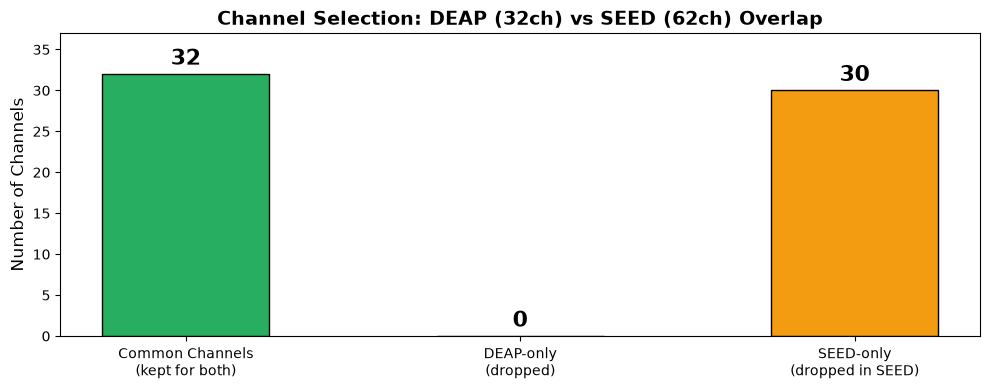

In [6]:
# Visualize channel overlap
fig, ax = plt.subplots(figsize=(10, 4))
categories = ['Common Channels\n(kept for both)', 'DEAP-only\n(dropped)', 'SEED-only\n(dropped in SEED)']
counts = [len(COMMON_CHANNELS), len(deap_only), len(seed_only)]
colors = ['#27ae60', '#e74c3c', '#f39c12']
bars = ax.bar(categories, counts, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=16)
ax.set_ylabel('Number of Channels', fontsize=12)
ax.set_title('Channel Selection: DEAP (32ch) vs SEED (62ch) Overlap', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) + 5)
plt.tight_layout()
plt.show()

## 6. DEAP Preprocessing Pipeline

The following steps are applied sequentially to each DEAP subject:

1. **Load** — Extract 32 EEG channels and labels from `.dat` file
2. **Baseline removal** — Remove the 3-second pre-stimulus period (384 samples)
3. **Channel selection** — Retain only the 32 common channels
4. **Bandpass filter** — 5th-order Butterworth, 4–45 Hz (retains theta, alpha, beta, gamma bands)
5. **Segmentation** — 1-second windows with 50% overlap (~119 segments per 60s trial)
6. **Z-score normalization** — Per channel across all segments of one subject

In [7]:
# --- Preprocessing functions ---

def load_deap_subject(filepath):
    """Load EEG data and labels from a DEAP subject file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data['data'][:, :32, :], data['labels']

def remove_baseline(eeg_data, baseline_samples):
    """Remove pre-stimulus baseline from each trial."""
    return eeg_data[:, :, baseline_samples:]

def select_channels(eeg_data, channel_indices):
    """Select specified channels from EEG data."""
    return eeg_data[:, channel_indices, :]

def bandpass_filter(data, low_freq, high_freq, srate, order=5):
    """Apply zero-phase Butterworth bandpass filter."""
    nyquist = srate / 2.0
    b, a = butter(order, [low_freq/nyquist, high_freq/nyquist], btype='band')
    filtered = np.zeros_like(data)
    for trial in range(data.shape[0]):
        for ch in range(data.shape[1]):
            filtered[trial, ch, :] = filtfilt(b, a, data[trial, ch, :])
    return filtered

def segment_data(data, window_samples, overlap_ratio=0.5):
    """Segment trials into overlapping windows."""
    step = int(window_samples * (1 - overlap_ratio))
    segments, trial_indices = [], []
    for trial in range(data.shape[0]):
        start = 0
        while start + window_samples <= data.shape[2]:
            segments.append(data[trial, :, start:start + window_samples])
            trial_indices.append(trial)
            start += step
    return np.array(segments), np.array(trial_indices)

def normalize_zscore(segments):
    """Z-score normalize per channel across all segments."""
    normalized = np.zeros_like(segments)
    for ch in range(segments.shape[1]):
        ch_data = segments[:, ch, :]
        mean, std = ch_data.mean(), ch_data.std()
        normalized[:, ch, :] = (ch_data - mean) / std if std > 0 else ch_data - mean
    return normalized

def prepare_labels(labels, trial_indices):
    """Create binary and 3-class labels mapped to segment level."""
    valence, arousal = labels[:, 0], labels[:, 1]
    bin_val = (valence > 5).astype(int)
    bin_aro = (arousal > 5).astype(int)
    three_class = np.ones(len(valence), dtype=int)
    three_class[valence > VALENCE_HIGH] = 2
    three_class[valence < VALENCE_LOW] = 0
    return {
        'binary_valence': bin_val[trial_indices],
        'binary_arousal': bin_aro[trial_indices],
        'three_class': three_class[trial_indices]
    }

print("All preprocessing functions defined.")

All preprocessing functions defined.


## 7. Pipeline Demonstration — Subject 01

Before running the full pipeline across all 32 subjects, we demonstrate each step on Subject 01 to verify correctness and visualize the effects.

In [8]:
# Step-by-step on Subject 01
eeg_s01, labels_s01 = load_deap_subject(os.path.join(DEAP_DATA_DIR, 's01.dat'))
print(f"1. Loaded:    {eeg_s01.shape} — 40 trials × 32 EEG channels × 8064 samples")

baseline_samples = BASELINE_SEC * DEAP_SRATE
eeg_s01 = remove_baseline(eeg_s01, baseline_samples)
print(f"2. Baseline:  {eeg_s01.shape} — removed {baseline_samples} samples ({BASELINE_SEC}s), 60s per trial remains")

eeg_s01_raw = eeg_s01.copy()  # Save for comparison plot
eeg_s01 = select_channels(eeg_s01, DEAP_COMMON_IDX)
print(f"3. Channels:  {eeg_s01.shape} — kept {len(DEAP_COMMON_IDX)} common channels")

eeg_s01 = bandpass_filter(eeg_s01, LOW_FREQ, HIGH_FREQ, DEAP_SRATE, FILTER_ORDER)
print(f"4. Filtered:  {eeg_s01.shape} — bandpass {LOW_FREQ}–{HIGH_FREQ} Hz applied")

window_samples = WINDOW_SEC * DEAP_SRATE
segments, trial_indices = segment_data(eeg_s01, window_samples, OVERLAP)
print(f"5. Segmented: {segments.shape} — {segments.shape[0]} segments of {WINDOW_SEC}s each")

segments = normalize_zscore(segments)
print(f"6. Normalized: mean={segments[:, 0, :].mean():.6f}, std={segments[:, 0, :].std():.6f} (channel FP1)")

1. Loaded:    (40, 32, 8064) — 40 trials × 32 EEG channels × 8064 samples
2. Baseline:  (40, 32, 7680) — removed 384 samples (3s), 60s per trial remains
3. Channels:  (40, 32, 7680) — kept 32 common channels
4. Filtered:  (40, 32, 7680) — bandpass 4.0–45.0 Hz applied
5. Segmented: (4760, 32, 128) — 4760 segments of 1s each
6. Normalized: mean=0.000000, std=1.000000 (channel FP1)


### Bandpass Filter Effect

The DEAP preprocessed data has already undergone basic filtering by the original authors (Koelstra et al., 2012). Our additional bandpass filter (4–45 Hz) strictly enforces the frequency range, removing any residual slow drift below 4 Hz and noise above 45 Hz. The effect is subtle because the input data is already semi-clean.

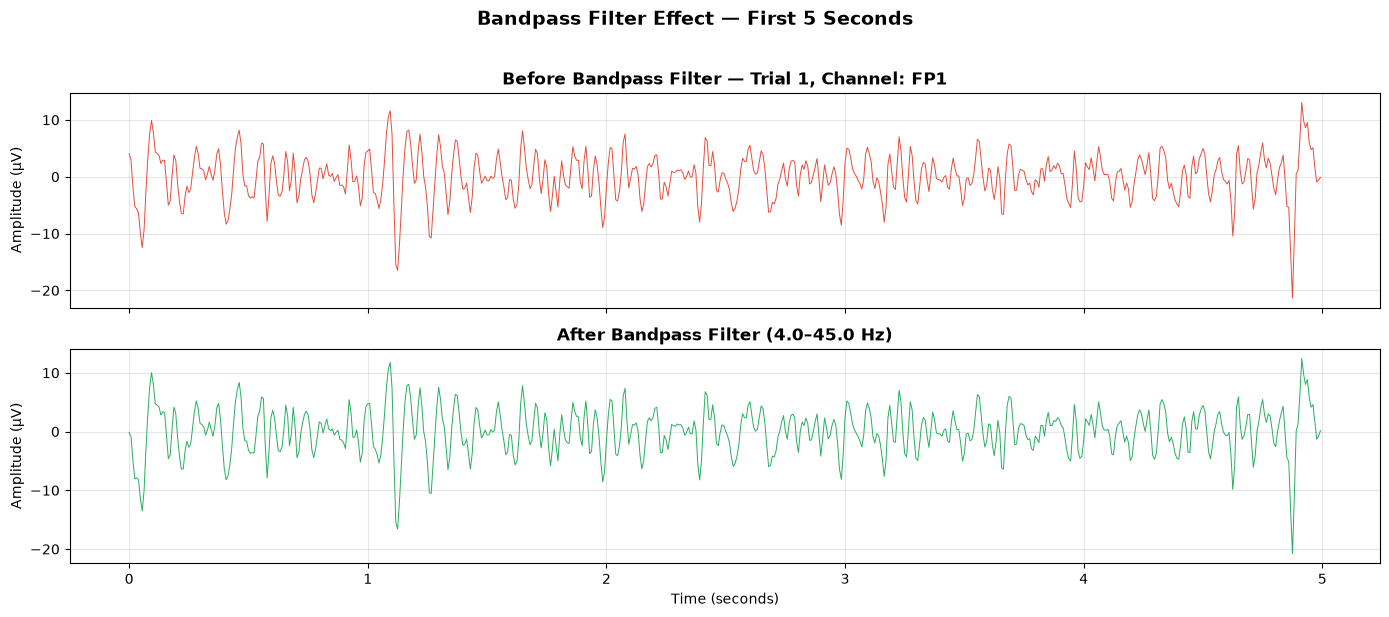

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
time_sec = np.arange(640) / DEAP_SRATE

eeg_raw_selected = select_channels(eeg_s01_raw, DEAP_COMMON_IDX)
axes[0].plot(time_sec, eeg_raw_selected[0, 0, :640], color='#e74c3c', linewidth=0.7)
axes[0].set_title(f'Before Bandpass Filter — Trial 1, Channel: {COMMON_CHANNELS[0]}', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)

eeg_filt_demo = bandpass_filter(eeg_raw_selected, LOW_FREQ, HIGH_FREQ, DEAP_SRATE, FILTER_ORDER)
axes[1].plot(time_sec, eeg_filt_demo[0, 0, :640], color='#27ae60', linewidth=0.7)
axes[1].set_title(f'After Bandpass Filter ({LOW_FREQ}–{HIGH_FREQ} Hz)', fontweight='bold')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Bandpass Filter Effect — First 5 Seconds', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Label Distribution — Subject 01

DEAP labels are self-assessed ratings on a 1–9 scale. We derive three label types:
- **Binary valence/arousal**: threshold at 5 (high > 5, low ≤ 5)
- **3-class**: valence > 5.5 → Positive, 4.5–5.5 → Neutral, < 4.5 → Negative (aligned with SEED categories)

Subject 01 shows a strong skew toward low valence and low arousal, indicating this participant generally reported calm/negative emotional states during the experiment.

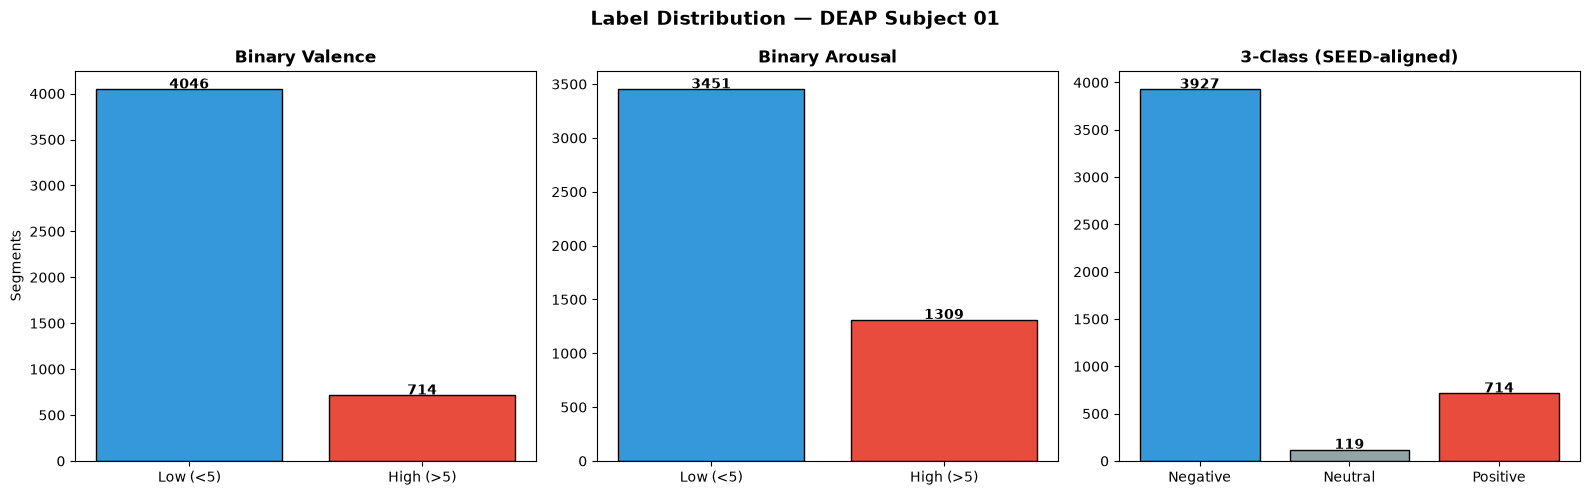

In [10]:
label_dict = prepare_labels(labels_s01, trial_indices)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vals, counts = np.unique(label_dict['binary_valence'], return_counts=True)
axes[0].bar(['Low (<5)', 'High (>5)'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Binary Valence', fontweight='bold')
axes[0].set_ylabel('Segments')
for i, c in enumerate(counts): axes[0].text(i, c+10, str(c), ha='center', fontweight='bold')

vals, counts = np.unique(label_dict['binary_arousal'], return_counts=True)
axes[1].bar(['Low (<5)', 'High (>5)'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Binary Arousal', fontweight='bold')
for i, c in enumerate(counts): axes[1].text(i, c+10, str(c), ha='center', fontweight='bold')

vals, counts = np.unique(label_dict['three_class'], return_counts=True)
axes[2].bar(['Negative', 'Neutral', 'Positive'][:len(counts)], counts, 
            color=['#3498db', '#95a5a6', '#e74c3c'][:len(counts)], edgecolor='black')
axes[2].set_title('3-Class (SEED-aligned)', fontweight='bold')
for i, c in enumerate(counts): axes[2].text(i, c+10, str(c), ha='center', fontweight='bold')

plt.suptitle('Label Distribution — DEAP Subject 01', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Process All 32 DEAP Subjects

The pipeline is applied to all 32 subjects. Each subject produces 4,760 segments (40 trials × ~119 segments per trial).

In [11]:
def preprocess_deap_subject(filepath):
    """Complete preprocessing pipeline for one DEAP subject."""
    eeg, labels = load_deap_subject(filepath)
    eeg = remove_baseline(eeg, BASELINE_SEC * DEAP_SRATE)
    eeg = select_channels(eeg, DEAP_COMMON_IDX)
    eeg = bandpass_filter(eeg, LOW_FREQ, HIGH_FREQ, DEAP_SRATE, FILTER_ORDER)
    segments, trial_idx = segment_data(eeg, WINDOW_SEC * DEAP_SRATE, OVERLAP)
    segments = normalize_zscore(segments)
    label_dict = prepare_labels(labels, trial_idx)
    return segments, label_dict

all_seg, all_bv, all_ba, all_3c, all_sid = [], [], [], [], []

print("Processing all 32 DEAP subjects...")
print("-" * 60)
for subj in range(1, 33):
    fp = os.path.join(DEAP_DATA_DIR, f's{subj:02d}.dat')
    if not os.path.exists(fp):
        print(f"  ⚠ Subject {subj:02d}: not found"); continue
    seg, lab = preprocess_deap_subject(fp)
    all_seg.append(seg); all_bv.append(lab['binary_valence'])
    all_ba.append(lab['binary_arousal']); all_3c.append(lab['three_class'])
    all_sid.append(np.full(len(seg), subj))
    print(f"  ✓ Subject {subj:02d}: {seg.shape[0]} segments")

X_deap = np.concatenate(all_seg)
y_valence = np.concatenate(all_bv)
y_arousal = np.concatenate(all_ba)
y_3class = np.concatenate(all_3c)
subject_ids = np.concatenate(all_sid)

print(f"\n{'='*60}")
print(f"DEAP COMPLETE: {X_deap.shape[0]:,} segments | shape: {X_deap.shape[1:]} | {len(np.unique(subject_ids))} subjects")

Processing all 32 DEAP subjects...
------------------------------------------------------------
  ✓ Subject 01: 4760 segments
  ✓ Subject 02: 4760 segments
  ✓ Subject 03: 4760 segments
  ✓ Subject 04: 4760 segments
  ✓ Subject 05: 4760 segments
  ✓ Subject 06: 4760 segments
  ✓ Subject 07: 4760 segments
  ✓ Subject 08: 4760 segments
  ✓ Subject 09: 4760 segments
  ✓ Subject 10: 4760 segments
  ✓ Subject 11: 4760 segments
  ✓ Subject 12: 4760 segments
  ✓ Subject 13: 4760 segments
  ✓ Subject 14: 4760 segments
  ✓ Subject 15: 4760 segments
  ✓ Subject 16: 4760 segments
  ✓ Subject 17: 4760 segments
  ✓ Subject 18: 4760 segments
  ✓ Subject 19: 4760 segments
  ✓ Subject 20: 4760 segments
  ✓ Subject 21: 4760 segments
  ✓ Subject 22: 4760 segments
  ✓ Subject 23: 4760 segments
  ✓ Subject 24: 4760 segments
  ✓ Subject 25: 4760 segments
  ✓ Subject 26: 4760 segments
  ✓ Subject 27: 4760 segments
  ✓ Subject 28: 4760 segments
  ✓ Subject 29: 4760 segments
  ✓ Subject 30: 4760 segments
  ✓ 

### Overall DEAP Label Distribution

The class distribution shown here is computed from the mirrored label columns, which were later found to be corrupted. These labels are superseded by the reconstruction in `00_label_rebuild.ipynb`; the official participant ratings give a 55.3 / 44.7 valence split.


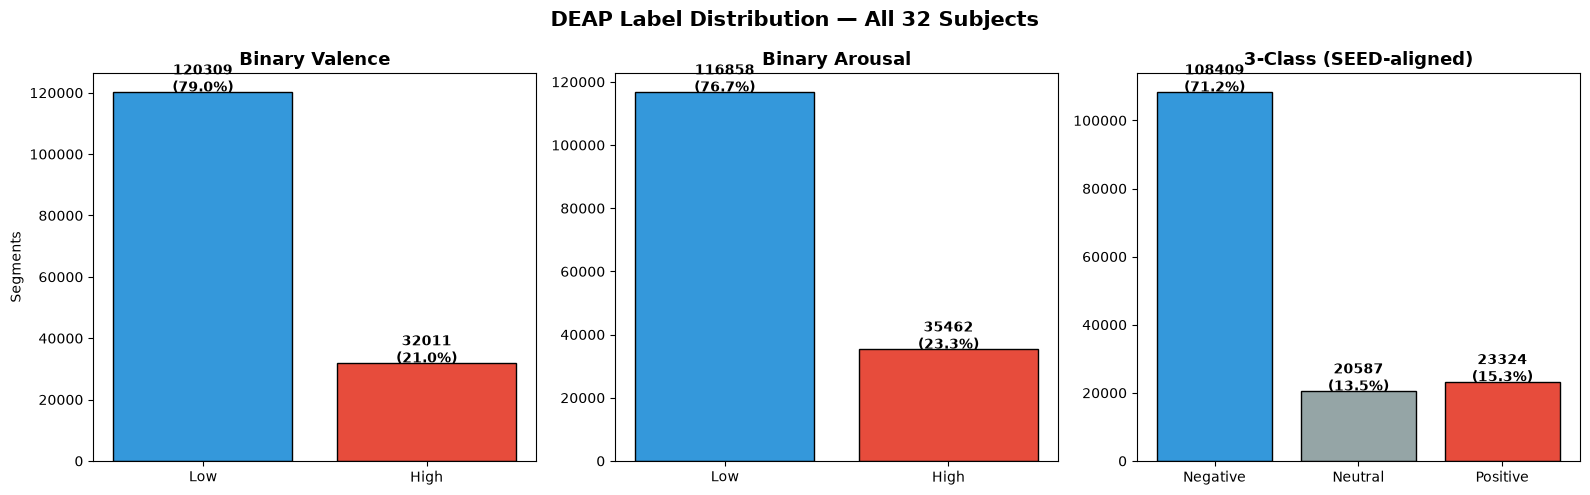

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y, title, names in [
    (axes[0], y_valence, 'Binary Valence', ['Low', 'High']),
    (axes[1], y_arousal, 'Binary Arousal', ['Low', 'High']),
    (axes[2], y_3class, '3-Class (SEED-aligned)', ['Negative', 'Neutral', 'Positive']),
]:
    vals, counts = np.unique(y, return_counts=True)
    colors = ['#3498db', '#e74c3c'] if len(names)==2 else ['#3498db', '#95a5a6', '#e74c3c']
    ax.bar(names[:len(counts)], counts, color=colors[:len(counts)], edgecolor='black')
    ax.set_title(title, fontweight='bold', fontsize=13)
    for i, c in enumerate(counts):
        ax.text(i, c+100, f'{c}\n({c/len(y)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylabel('Segments')
plt.suptitle('DEAP Label Distribution — All 32 Subjects', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part B: SEED Dataset (External Test Set)
---

## 9. SEED Data Exploration

SEED stores preprocessed EEG recordings as MATLAB `.mat` files, one file per subject per session. Each file contains 15 trials (one per film clip) with 62 channels at 200 Hz. Unlike DEAP, trial durations vary because film clips have different lengths.

In [13]:
# List SEED files
mat_files = sorted([f for f in os.listdir(SEED_DATA_DIR) if f.endswith('.mat')])
print(f"Total .mat files: {len(mat_files)} (15 subjects × 3 sessions + extra)")

# Inspect one file
sample = sio.loadmat(os.path.join(SEED_DATA_DIR, mat_files[0]))
trial_keys = sorted([k for k in sample.keys() if not k.startswith('__')],
                     key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))

print(f"\nFile: {mat_files[0]}")
print(f"Trials: {len(trial_keys)}")
for key in trial_keys[:3]:
    d = sample[key]
    if d.ndim == 2 and min(d.shape) > 1:
        shape = d.shape if d.shape[0] < d.shape[1] else (d.shape[1], d.shape[0])
        print(f"  '{key}': {shape[0]} channels × {shape[1]} samples ({shape[1]/SEED_SRATE:.0f}s)")
print(f"  ... ({len(trial_keys)} trials total)")

Total .mat files: 46 (15 subjects × 3 sessions + extra)

File: 10_20131130.mat
Trials: 15
  'ww_eeg1': 62 channels × 47001 samples (235s)
  'ww_eeg2': 62 channels × 46601 samples (233s)
  'ww_eeg3': 62 channels × 41201 samples (206s)
  ... (15 trials total)


## 10. SEED Preprocessing Pipeline

The same preprocessing logic is applied, with one additional step: **resampling from 200 Hz to 128 Hz** to match DEAP's sampling rate. This ensures both datasets produce segments with identical dimensions.

Steps: Load → Select 32 common channels → Bandpass filter (4–45 Hz) → Resample (200 → 128 Hz) → Segment (1s, 50% overlap) → Z-score normalize

SEED labels are pre-assigned per film clip: 1 = Positive, 0 = Neutral, -1 = Negative. These are remapped to match DEAP's 3-class encoding: 0 = Negative, 1 = Neutral, 2 = Positive.

In [14]:
def bandpass_filter_1d(signal, low_freq, high_freq, srate, order=5):
    nyquist = srate / 2.0
    b, a = butter(order, [low_freq/nyquist, high_freq/nyquist], btype='band')
    return filtfilt(b, a, signal)

def resample_signal(signal, orig_srate, target_srate):
    return resample(signal, int(len(signal) * target_srate / orig_srate))

def segment_1d_trial(trial_data, window_samples, overlap_ratio=0.5):
    step = int(window_samples * (1 - overlap_ratio))
    segments = []
    start = 0
    while start + window_samples <= trial_data.shape[1]:
        segments.append(trial_data[:, start:start + window_samples])
        start += step
    return np.array(segments) if segments else np.array([]).reshape(0, trial_data.shape[0], window_samples)

def process_seed_file(filepath):
    """Complete preprocessing for one SEED .mat file."""
    mat_data = sio.loadmat(filepath)
    trial_keys = sorted([k for k in mat_data.keys() if not k.startswith('__')],
                        key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
    
    all_segments, all_labels = [], []
    window_samples = int(WINDOW_SEC * TARGET_SRATE)
    
    for trial_idx, key in enumerate(trial_keys):
        if trial_idx >= len(SEED_LABELS): break
        trial = mat_data[key]
        if trial.ndim != 2 or min(trial.shape) < 2: continue
        if trial.shape[0] > trial.shape[1]: trial = trial.T
        if trial.shape[0] < max(SEED_COMMON_IDX) + 1: continue
        
        # Select channels → Filter → Resample → Segment
        trial = trial[SEED_COMMON_IDX, :]
        filtered = np.array([bandpass_filter_1d(trial[ch], LOW_FREQ, HIGH_FREQ, SEED_SRATE, FILTER_ORDER) 
                            for ch in range(trial.shape[0])])
        resampled = np.array([resample_signal(filtered[ch], SEED_SRATE, TARGET_SRATE) 
                             for ch in range(filtered.shape[0])])
        segs = segment_1d_trial(resampled, window_samples, OVERLAP)
        
        if len(segs) > 0:
            all_segments.append(segs)
            all_labels.append(np.full(len(segs), SEED_LABELS[trial_idx] + 1))  # -1→0, 0→1, 1→2
    
    if all_segments:
        return np.concatenate(all_segments), np.concatenate(all_labels)
    return np.array([]), np.array([])

print("SEED preprocessing functions defined.")

SEED preprocessing functions defined.


In [15]:
all_seg, all_lab, all_sid = [], [], []

print("Processing all SEED files...")
print("-" * 70)
for mat_file in mat_files:
    seg, lab = process_seed_file(os.path.join(SEED_DATA_DIR, mat_file))
    if len(seg) > 0:
        all_seg.append(seg); all_lab.append(lab)
        subj_id = int(mat_file.split('_')[0])
        all_sid.append(np.full(len(seg), subj_id))
        print(f"  ✓ {mat_file}: {seg.shape[0]} segments | Pos={sum(lab==2)} Neu={sum(lab==1)} Neg={sum(lab==0)}")

X_seed = np.concatenate(all_seg)
y_seed = np.concatenate(all_lab)
seed_subj_ids = np.concatenate(all_sid)

print(f"\n{'='*70}")
print(f"SEED COMPLETE: {X_seed.shape[0]:,} segments | shape: {X_seed.shape[1:]} | {len(np.unique(seed_subj_ids))} subjects")

Processing all SEED files...
----------------------------------------------------------------------
  ✓ 10_20131130.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 10_20131204.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 10_20131211.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 11_20140618.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 11_20140625.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 11_20140630.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 12_20131127.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 12_20131201.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 12_20131207.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 13_20140527.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 13_20140603.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 13_20140610.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 14_20140601.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 14_20140615.mat: 6773 segments | Pos=2335 Neu=2203 Neg=2235
  ✓ 

### SEED Label Distribution

SEED uses a balanced experimental design with 5 positive, 5 neutral, and 5 negative film clips per session. The slight variation in segment counts across classes is due to film clips having different durations — longer clips produce more 1-second segments after slicing.

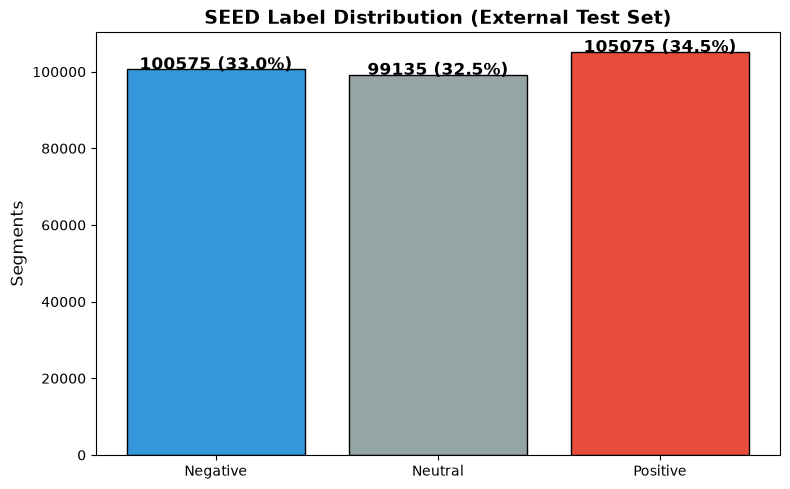

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
vals, counts = np.unique(y_seed, return_counts=True)
names = ['Negative', 'Neutral', 'Positive']
colors = ['#3498db', '#95a5a6', '#e74c3c']
bars = ax.bar(names[:len(counts)], counts, color=colors[:len(counts)], edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{c} ({c/len(y_seed)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Segments', fontsize=12)
ax.set_title('SEED Label Distribution (External Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part C: Cross-Dataset Compatibility
---

## 11. Compatibility Verification

The critical requirement for cross-dataset evaluation is that both datasets produce segments with identical dimensions. This enables a model trained on DEAP to be directly applied to SEED without architectural changes.

In [17]:
print("CROSS-DATASET COMPATIBILITY CHECK")
print("=" * 55)
print(f"{'':>20} {'DEAP':>15} {'SEED':>15}")
print("-" * 55)
print(f"{'Role':>20} {'Train + Val':>15} {'External Test':>15}")
print(f"{'Total segments':>20} {X_deap.shape[0]:>15,} {X_seed.shape[0]:>15,}")
print(f"{'Channels':>20} {X_deap.shape[1]:>15} {X_seed.shape[1]:>15}")
print(f"{'Window samples':>20} {X_deap.shape[2]:>15} {X_seed.shape[2]:>15}")
print(f"{'Sampling rate':>20} {'128 Hz':>15} {'128 Hz':>15}")
print(f"{'Subjects':>20} {len(np.unique(subject_ids)):>15} {len(np.unique(seed_subj_ids)):>15}")

ch_ok = X_deap.shape[1] == X_seed.shape[1]
win_ok = X_deap.shape[2] == X_seed.shape[2]
print(f"\nChannels match: {'✓' if ch_ok else '✗'}")
print(f"Window match:   {'✓' if win_ok else '✗'}")
print(f"\n{'✓ Fully compatible for cross-dataset evaluation.' if ch_ok and win_ok else '✗ Shape mismatch.'}")

CROSS-DATASET COMPATIBILITY CHECK
                                DEAP            SEED
-------------------------------------------------------
                Role     Train + Val   External Test
      Total segments         152,320         304,785
            Channels              32              32
      Window samples             128             128
       Sampling rate          128 Hz          128 Hz
            Subjects              32              15

Channels match: ✓
Window match:   ✓

✓ Fully compatible for cross-dataset evaluation.


## 12. Data Split Strategy

**Leave-One-Subject-Out (LOSO) Cross-Validation** is used for DEAP to prevent data leakage. In each fold, 31 subjects are used for training and 1 subject for validation, repeated across all 32 subjects. This ensures the model is evaluated on entirely unseen subjects.

**SEED is reserved as an external test set** — no SEED data is used during training or validation. This setup tests whether the model has learned genuinely transferable emotion representations.

In [18]:
def get_loso_splits(subject_ids):
    splits = []
    for val_subj in np.unique(subject_ids):
        train_idx = np.where(subject_ids != val_subj)[0]
        val_idx = np.where(subject_ids == val_subj)[0]
        splits.append((train_idx, val_idx))
    return splits

splits = get_loso_splits(subject_ids)
print(f"LOSO Cross-Validation: {len(splits)} folds")
print(f"  Each fold: {len(splits[0][0]):,} train ({len(splits[0][0])/len(subject_ids)*100:.1f}%) | "
      f"{len(splits[0][1]):,} val ({len(splits[0][1])/len(subject_ids)*100:.1f}%)")
print(f"\nNo data leakage: train and val never share subjects. ✓")
print(f"SEED: external test only — no training/fine-tuning. ✓")

LOSO Cross-Validation: 32 folds
  Each fold: 147,560 train (96.9%) | 4,760 val (3.1%)

No data leakage: train and val never share subjects. ✓
SEED: external test only — no training/fine-tuning. ✓


## 13. Save All Processed Data

In [19]:
# Save DEAP
np.save(os.path.join(OUTPUT_DIR, 'X_deap.npy'), X_deap)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_valence.npy'), y_valence)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_arousal.npy'), y_arousal)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_3class.npy'), y_3class)
np.save(os.path.join(OUTPUT_DIR, 'deap_subject_ids.npy'), subject_ids)
np.save(os.path.join(OUTPUT_DIR, 'common_channels.npy'), np.array(COMMON_CHANNELS))
np.save(os.path.join(OUTPUT_DIR, 'seed_common_idx.npy'), np.array(SEED_COMMON_IDX))

# Save SEED
np.save(os.path.join(OUTPUT_DIR, 'X_seed.npy'), X_seed)
np.save(os.path.join(OUTPUT_DIR, 'y_seed.npy'), y_seed)
np.save(os.path.join(OUTPUT_DIR, 'seed_subject_ids.npy'), seed_subj_ids)

print(f"All data saved to: {OUTPUT_DIR}\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.npy'):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024**2)
        print(f"  {f}: {size:.1f} MB")

All data saved to: V:\Data_Analytics\case study 2\processed

  X_deap.npy: 4760.0 MB
  X_seed.npy: 9524.5 MB
  common_channels.npy: 0.0 MB
  deap_subject_ids.npy: 1.2 MB
  seed_common_idx.npy: 0.0 MB
  seed_subject_ids.npy: 2.3 MB
  y_deap_3class.npy: 1.2 MB
  y_deap_arousal.npy: 1.2 MB
  y_deap_valence.npy: 1.2 MB
  y_seed.npy: 2.3 MB


## 14. Preprocessing Summary

| Step | DEAP | SEED |
|------|------|------|
| Raw format | Pickle `.dat` (32 EEG + 8 peripheral) | MATLAB `.mat` (62 EEG channels) |
| Channels retained | 32 (all common) | 32 (common subset of 62) |
| Baseline removal | 3s removed (384 samples) | Not applicable |
| Bandpass filter | Butterworth 4–45 Hz, order 5 | Butterworth 4–45 Hz, order 5 |
| Resampling | Not needed (already 128 Hz) | 200 Hz → 128 Hz |
| Segmentation | 1s windows, 50% overlap → ~119/trial | 1s windows, 50% overlap |
| Normalization | Z-score per channel per subject | Z-score per channel per subject |
| Label encoding | Binary (threshold=5) + 3-class | 3-class: -1→0, 0→1, 1→2 |
| Final segment shape | (152,320 × 32 × 128) | (304,785 × 32 × 128) |
| Split strategy | LOSO (32 folds) | External test only |
| Class balance | Imbalanced (71% negative) | Balanced (~33% each) |

### Key Findings
1. All 32 DEAP channels exist in SEED — no information loss from channel alignment.
2. DEAP shows significant class imbalance in the 3-class setting, requiring mitigation during training.
3. SEED provides a well-balanced external test set with nearly equal representation across emotion classes.
4. Both datasets produce segments with identical dimensions (32 × 128), confirming cross-dataset compatibility.

### Next Steps (Report 2)
- Feature engineering: Differential Entropy, Power Spectral Density, DASM/RASM, PLV
- Baseline model training: SVM, Random Forest, CNN-only, LSTM-only, BiLSTM-only

---
*Sanjeev Veeramani | M.Sc. Applied Data Science and Analytics | SRH University Heidelberg | Report 1 — July 2026*